# Fake News Detection - NLP Midterm Project
Group 5, Section D

In [1]:
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

warnings.filterwarnings("ignore")

print("Done")

Done


In [2]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\AKiB\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\AKiB\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AKiB\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\AKiB\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\AKiB\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Loading Dataset 1 (ISOT Fake and Real News)

In [3]:
fake_df = pd.read_csv("dataset/Fake.csv")
true_df = pd.read_csv("dataset/True.csv")

fake_df["label"] = 1
true_df["label"] = 0

df1 = pd.concat([fake_df, true_df], ignore_index=True)
df1 = df1.dropna(subset=["title", "text"]).reset_index(drop=True)
df1 = df1.sample(frac=1, random_state=42).reset_index(drop=True)

df1["content"] = df1["title"].astype(str) + " " + df1["text"].astype(str)
df1.head()

,title,text,subject,date,label,content
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0,Puerto Rico expects U.S. to lift Jones Act shi...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1,OOPS: Trump Just Accidentally Confirmed He Le...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0,Donald Trump heads for Scotland to reopen a go...


## Loading Dataset 2 (WELFake)

In [4]:
df2 = pd.read_csv("dataset/WELFake_Dataset.csv")
df2.columns = [c.strip().lower() for c in df2.columns]
if "unnamed: 0" in df2.columns:
    df2 = df2.drop(columns=["unnamed: 0"])

df2["title"] = df2["title"].fillna("")
df2 = df2.dropna(subset=["text", "label"]).reset_index(drop=True)
df2["label"] = df2["label"].astype(int)
df2 = df2.sample(frac=1, random_state=42).reset_index(drop=True)

df2["content"] = df2["title"].astype(str) + " " + df2["text"].astype(str)
df2.head()

,title,text,label,content
0,"Trump Tweets Deranged, Self-Congratulatory ‘F...",Trump s ongoing meltdown over fake news (the...,1,"Trump Tweets Deranged, Self-Congratulatory ‘F..."
1,Rio Olympics: Drama in the Pool and a Super Tu...,Women’s Breaststroke: In the days leading up...,0,Rio Olympics: Drama in the Pool and a Super Tu...
2,4 DEAD TEENAGERS In Two Weeks…Illegal Immigran...,It was only a matter of time We can t keep our...,1,4 DEAD TEENAGERS In Two Weeks…Illegal Immigran...
3,It’s Not Just Fox: Why Women Don’t Report Sexu...,A male colleague grabbing her leg. Another one...,0,It’s Not Just Fox: Why Women Don’t Report Sexu...
4,EU Parliament names press room after murdered ...,STRASBOURG (Reuters) - The European Parliament...,0,EU Parliament names press room after murdered ...


## Text Cleaning (Regex)

In [5]:
url_pattern = re.compile(r"https?://\S+|www\.\S+")
mention_pattern = re.compile(r"@\w+")
hashtag_pattern = re.compile(r"#\w+")
html_pattern = re.compile(r"<.*?>|&\w+;")
non_letter_pattern = re.compile(r"[^a-zA-Z\s]")
space_pattern = re.compile(r"\s+")

mojibake_map = {
    "\u00e2\u20ac\u2122": "'",
    "\u00e2\u20ac\u0153": '"',
    "\u00e2\u20ac": '"',
}

def clean_text(text):
    text = str(text)
    for bad, good in mojibake_map.items():
        text = text.replace(bad, good)
    text = url_pattern.sub(" ", text)
    text = html_pattern.sub(" ", text)
    text = mention_pattern.sub(" ", text)
    text = hashtag_pattern.sub(" ", text)
    text = non_letter_pattern.sub(" ", text)
    text = space_pattern.sub(" ", text)
    return text.strip()

df1["clean"] = df1["content"].apply(clean_text)
df2["clean"] = df2["content"].apply(clean_text)
df1[["content", "clean"]].head(2)

,content,clean
0,Ben Stein Calls Out 9th Circuit Court: Committ...,Ben Stein Calls Out th Circuit Court Committed...
1,Trump drops Steve Bannon from National Securit...,Trump drops Steve Bannon from National Securit...


## Tokenization, Case Folding, Stop Word Removal and Lemmatization

In [6]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df1["processed"] = df1["clean"].apply(preprocess)
df2["processed"] = df2["clean"].apply(preprocess)
df1[["clean", "processed"]].head(2)

,clean,processed
0,Ben Stein Calls Out th Circuit Court Committed...,ben stein call th circuit court committed coup...
1,Trump drops Steve Bannon from National Securit...,trump drop steve bannon national security coun...


## Train-Test Split

In [7]:
train1, test1 = train_test_split(df1, test_size=0.2, stratify=df1["label"], random_state=42)
train2, test2 = train_test_split(df2, test_size=0.2, stratify=df2["label"], random_state=42)

y_train1, y_test1 = train1["label"].values, test1["label"].values
y_train2, y_test2 = train2["label"].values, test2["label"].values

print(train1.shape, test1.shape)
print(train2.shape, test2.shape)

(35918, 8) (8980, 8)
(57676, 6) (14419, 6)


## Bag of Words and TF-IDF Vectorization - Dataset 1

In [8]:
bow_vectorizer1 = CountVectorizer()
X_train1_bow = bow_vectorizer1.fit_transform(train1["processed"])
X_test1_bow = bow_vectorizer1.transform(test1["processed"])

tfidf_vectorizer1 = TfidfVectorizer()
X_train1_tfidf = tfidf_vectorizer1.fit_transform(train1["processed"])
X_test1_tfidf = tfidf_vectorizer1.transform(test1["processed"])

print(X_train1_bow.shape, X_train1_tfidf.shape)

(35918, 87299) (35918, 87299)


## Bag of Words and TF-IDF Vectorization - Dataset 2

In [9]:
bow_vectorizer2 = CountVectorizer()
X_train2_bow = bow_vectorizer2.fit_transform(train2["processed"])
X_test2_bow = bow_vectorizer2.transform(test2["processed"])

tfidf_vectorizer2 = TfidfVectorizer()
X_train2_tfidf = tfidf_vectorizer2.fit_transform(train2["processed"])
X_test2_tfidf = tfidf_vectorizer2.transform(test2["processed"])

print(X_train2_bow.shape, X_train2_tfidf.shape)

(57676, 160807) (57676, 160807)


## Evaluation Function

In [10]:
results = []

def run_model(model, X_train, y_train, X_test, y_test, algo_name, rep_name, dataset_name):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results.append({
        "Algorithm": algo_name,
        "Representation": rep_name,
        "Dataset": dataset_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
    })
    print(algo_name, rep_name, dataset_name)
    print("Accuracy:", round(acc, 4), "Precision:", round(prec, 4), "Recall:", round(rec, 4), "F1:", round(f1, 4))
    print(confusion_matrix(y_test, preds))
    return model

## Naive Bayes - Dataset 1

In [11]:
run_model(MultinomialNB(), X_train1_bow, y_train1, X_test1_bow, y_test1, "Naive Bayes", "BoW", "Dataset 1")

Naive Bayes BoW Dataset 1
Accuracy: 0.9543 Precision: 0.9565 Recall: 0.9561 F1: 0.9563
[[4080  204]
 [ 206 4490]]


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [12]:
run_model(MultinomialNB(), X_train1_tfidf, y_train1, X_test1_tfidf, y_test1, "Naive Bayes", "TF-IDF", "Dataset 1")

Naive Bayes TF-IDF Dataset 1
Accuracy: 0.9384 Precision: 0.9335 Recall: 0.95 F1: 0.9416
[[3966  318]
 [ 235 4461]]


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## Logistic Regression - Dataset 1

In [13]:
run_model(LogisticRegression(), X_train1_bow, y_train1, X_test1_bow, y_test1, "Logistic Regression", "BoW", "Dataset 1")

Logistic Regression BoW Dataset 1
Accuracy: 0.9963 Precision: 0.9966 Recall: 0.9964 F1: 0.9965
[[4268   16]
 [  17 4679]]


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
run_model(LogisticRegression(), X_train1_tfidf, y_train1, X_test1_tfidf, y_test1, "Logistic Regression", "TF-IDF", "Dataset 1")

Logistic Regression TF-IDF Dataset 1
Accuracy: 0.989 Precision: 0.9923 Recall: 0.9866 F1: 0.9894
[[4248   36]
 [  63 4633]]


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Support Vector Machine - Dataset 1

In [15]:
run_model(LinearSVC(), X_train1_bow, y_train1, X_test1_bow, y_test1, "SVM", "BoW", "Dataset 1")

SVM BoW Dataset 1
Accuracy: 0.9961 Precision: 0.996 Recall: 0.9966 F1: 0.9963
[[4265   19]
 [  16 4680]]


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [16]:
run_model(LinearSVC(), X_train1_tfidf, y_train1, X_test1_tfidf, y_test1, "SVM", "TF-IDF", "Dataset 1")

SVM TF-IDF Dataset 1
Accuracy: 0.9955 Precision: 0.996 Recall: 0.9955 F1: 0.9957
[[4265   19]
 [  21 4675]]


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


## Naive Bayes - Dataset 2

In [17]:
run_model(MultinomialNB(), X_train2_bow, y_train2, X_test2_bow, y_test2, "Naive Bayes", "BoW", "Dataset 2")

Naive Bayes BoW Dataset 2
Accuracy: 0.8991 Precision: 0.8989 Recall: 0.9056 F1: 0.9022
[[6251  755]
 [ 700 6713]]


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [18]:
run_model(MultinomialNB(), X_train2_tfidf, y_train2, X_test2_tfidf, y_test2, "Naive Bayes", "TF-IDF", "Dataset 2")

Naive Bayes TF-IDF Dataset 2
Accuracy: 0.8682 Precision: 0.8566 Recall: 0.893 F1: 0.8744
[[5898 1108]
 [ 793 6620]]


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## Logistic Regression - Dataset 2

In [19]:
run_model(LogisticRegression(), X_train2_bow, y_train2, X_test2_bow, y_test2, "Logistic Regression", "BoW", "Dataset 2")

Logistic Regression BoW Dataset 2
Accuracy: 0.9621 Precision: 0.9508 Recall: 0.9768 F1: 0.9636
[[6631  375]
 [ 172 7241]]


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
run_model(LogisticRegression(), X_train2_tfidf, y_train2, X_test2_tfidf, y_test2, "Logistic Regression", "TF-IDF", "Dataset 2")

Logistic Regression TF-IDF Dataset 2
Accuracy: 0.951 Precision: 0.9448 Recall: 0.9607 F1: 0.9527
[[6590  416]
 [ 291 7122]]


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Support Vector Machine - Dataset 2

In [21]:
run_model(LinearSVC(), X_train2_bow, y_train2, X_test2_bow, y_test2, "SVM", "BoW", "Dataset 2")

SVM BoW Dataset 2
Accuracy: 0.9542 Precision: 0.943 Recall: 0.9694 F1: 0.956
[[6572  434]
 [ 227 7186]]


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [22]:
run_model(LinearSVC(), X_train2_tfidf, y_train2, X_test2_tfidf, y_test2, "SVM", "TF-IDF", "Dataset 2")

SVM TF-IDF Dataset 2
Accuracy: 0.9673 Precision: 0.959 Recall: 0.9781 F1: 0.9685
[[6696  310]
 [ 162 7251]]


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


## Final Results Table

In [23]:
results_df = pd.DataFrame(results)

table = results_df.pivot(index=["Algorithm", "Representation"], columns="Dataset",
                          values=["Accuracy", "Precision", "Recall", "F1"])
table = table.swaplevel(axis=1).sort_index(axis=1, level=0)
table

Dataset                            Dataset 1                                \
                                    Accuracy        F1 Precision    Recall   
Algorithm           Representation                                           
Logistic Regression BoW             0.996325  0.996486  0.996592  0.996380   
                    TF-IDF          0.988976  0.989429  0.992290  0.986584   
Naive Bayes         BoW             0.954343  0.956337  0.956540  0.956133   
                    TF-IDF          0.938419  0.941636  0.933459  0.949957   
SVM                 BoW             0.996102  0.996275  0.995957  0.996593   
                    TF-IDF          0.995546  0.995740  0.995952  0.995528   

Dataset                            Dataset 2                                
                                    Accuracy        F1 Precision    Recall  
Algorithm           Representation                                          
Logistic Regression BoW             0.962064  0.963604  0.950762  0.976798  
                    TF-IDF          0.950967  0.952712  0.944813  0.960745  
Naive Bayes         BoW             0.899091  0.902224  0.898902  0.905571  
                    TF-IDF          0.868160  0.874447  0.856625  0.893026  
SVM                 BoW             0.954158  0.956030  0.943045  0.969378  
                    TF-IDF          0.967265  0.968479  0.959000  0.978146

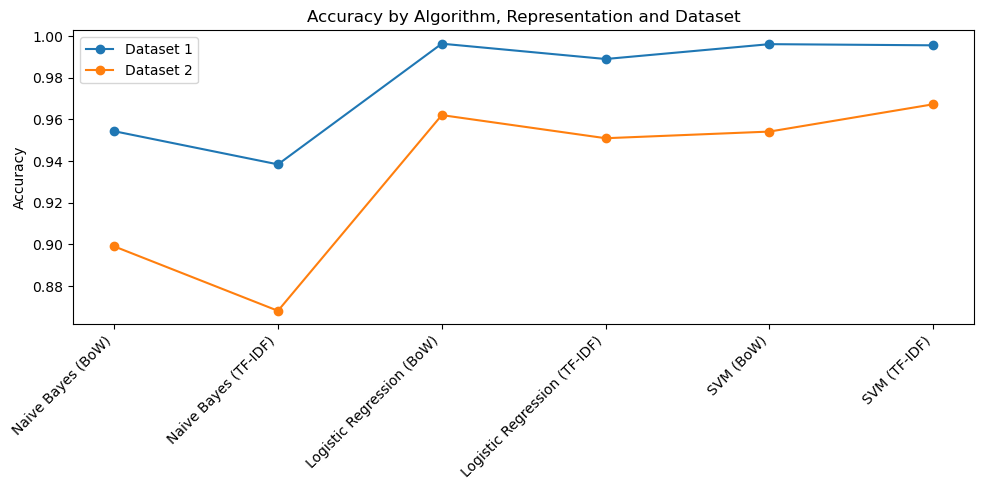

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
for dataset in results_df["Dataset"].unique():
    subset = results_df[results_df["Dataset"] == dataset]
    labels = subset["Algorithm"] + " (" + subset["Representation"] + ")"
    ax.plot(labels, subset["Accuracy"], marker="o", label=dataset)

ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Algorithm, Representation and Dataset")
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()